In [ ]:
#  Extract the data from figure 4 a in the paper: (Hueng et al.. Levi, 2025)  [Overall survival according to time-of-day of combined immuno-chemotherapy for advanced non-small cell lung cancer: a bicentric bicontinental study Zhe Huang]
# Calc a representative Weibull ditribution function for the baseline (1pm for Figure 4 - Huang et al.. Levi, 2025)
# Then use the data extracted from the figure (4a) for calculating the shift in survival when the drug is administered in a specific hour.
#  Then create two figures:
#  1 - reaching out to the clinic randomly (continously) during the day and the new drug is shifter to morning administration
#  2 - Kaplan Meier curves for simiulated two drugs effects (one that is better in the morning)

In [13]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.plotting import add_at_risk_counts
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import matplotlib.ticker as ticker
import os
import json
from datetime import datetime
import matplotlib.ticker as ticker
from datetime import datetime
import matplotlib.colors as mcolors 

In [3]:
# ==============================================================================
# PART 0: CLICK CURVE FROM HAZARD RATIO FIGURE 4a HUANG ET AL., 2025
# ==============================================================================

# Store clicks here
clicked_points = []

def get_coords(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN: # Capture Left Mouse Click
        print(f"--> CLICK DETECTED! X={x}, Y={y}")
        clicked_points.append((x, y))
        
        # Visual Feedback: Draw a red circle where you clicked
        cv2.circle(img, (x, y), 5, (0, 0, 255), -1) 
        cv2.imshow("CLICK ON THE 4 POINTS", img)

# 1. Load the image
image_path = "Hueng_fig_4a.png" # Make sure this matches your file
img = cv2.imread(image_path)

if img is None:
    print("Error: Could not load image. Check the file name.")
else:
    print("INSTRUCTIONS:")
    print("1. A window will pop up.")
    print("2. Click on these 4 locations in order:")
    print("   - Start of X-Axis (Time=9)")
    print("   - End of X-Axis (Time=18)")
    print("   - Bottom line (HR=0.0)")
    print("   - Top line (HR=4.0)")
    print("3. Watch this terminal window for the numbers.")
    print("4. Press any key on your keyboard to close the window when done.")
    print("-" * 30)

    # 2. Show the window and listen for mouse clicks
    cv2.imshow("CLICK ON THE 4 POINTS", img)
    cv2.setMouseCallback("CLICK ON THE 4 POINTS", get_coords)

    # 3. Wait until a key is pressed to close
    cv2.waitKey(0)
    cv2.destroyAllWindows()
    
    print("-" * 30)
    print("COPY THESE NUMBERS INTO YOUR MAIN SCRIPT:")
    if len(clicked_points) >= 4:
        print(f"x_pixel_start = {clicked_points[0][0]}")
        print(f"x_pixel_end   = {clicked_points[1][0]}")
        print(f"y_pixel_bottom = {clicked_points[2][1]}")
        print(f"y_pixel_top    = {clicked_points[3][1]}")
    else:
        print("You didn't click 4 times. Run the script again.")

INSTRUCTIONS:
1. A window will pop up.
2. Click on these 4 locations in order:
   - Start of X-Axis (Time=9)
   - End of X-Axis (Time=18)
   - Bottom line (HR=0.0)
   - Top line (HR=4.0)
3. Watch this terminal window for the numbers.
4. Press any key on your keyboard to close the window when done.
------------------------------
------------------------------
COPY THESE NUMBERS INTO YOUR MAIN SCRIPT:
You didn't click 4 times. Run the script again.


In [2]:

# ==============================================================================
# PART 1: EXTRACT CURVE FROM HAZARD RATIO FIGURE 4a HUANG ET AL., 2025
# ==============================================================================

def get_hr_curve_from_clicks(plot_flag=False, save_csv=False, print_head=False, path_save_fig=None):
    # ==========================================
    # 1. RAW DATA
    # ==========================================
    # The 10 points there were clicked: (Pixel_X, Pixel_Y)
    raw_points = [
        (77, 307),  # 09:00
        (166, 314), 
        (227, 290), 
        (248, 272), # 13:00, HR=1.0 (The Anchor)
        (301, 182), 
        (342, 120), 
        (376, 102), # Peak
        (410, 111), 
        (435, 124), 
        (464, 138)  # 18:00
    ]
    
    # Separate into lists
    x_pixels = np.array([p[0] for p in raw_points])
    y_pixels = np.array([p[1] for p in raw_points])

    # ==========================================
    # 2. CALIBRATION 
    # ==========================================
    
    # X-AXIS MAPPING
    # Pixel 77  = 09:00 (Start)
    # Pixel 464 = 18:3=00 (End)
    x_pixel_start = 77.0
    x_pixel_end   = 464.0
    time_start = 9
    time_end   = 18

    # Y-AXIS MAPPING
    # We use the distance between your "HR=1.0" click and the peak/trough to estimate scale.
    # Based on calculation: ~90 pixels = 1.0 Hazard Ratio unit.
    # Therefore, HR=0.0 (bottom axis) is at approx Pixel 362.
    # Therefore, HR=3.5 (top axis) is at approx Pixel 47.
    
    y_pixel_hr_0   = 362.0  # Calculated pixel for HR=0.0
    y_pixel_hr_1   = 272.0  # Your actual click for HR=1.0


    # ==========================================
    # 3. CONVERSION LOGIC
    # ==========================================
    def map_x(px):
        fraction = (px - x_pixel_start) / (x_pixel_end - x_pixel_start)
        return time_start + fraction * (time_end - time_start)

    def map_y(py):
        # Linear mapping based on the 0.0 and 1.0 anchors
        # Formula: HR = 1.0 - (Pixel - Pixel_at_HR1) / Pixels_Per_Unit
        pixels_per_unit = y_pixel_hr_0 - y_pixel_hr_1 # 362 - 272 = 90
        return 1.0 + (y_pixel_hr_1 - py) / pixels_per_unit
    # Convert raw pixels to real scientific data
    real_time = map_x(x_pixels)
    real_hr   = map_y(y_pixels)

    # ==========================================
    # 4. SMOOTHING (Cubic Spline)
    # ==========================================
    # Fit a smooth curve through your 10 points
    f_smooth = interp1d(real_time, real_hr, kind='cubic')
    
    # Generate data for every 15 minutes (0.25 hours)
    time_smooth = np.linspace(9.0, 18.0, num=37) # 37 points from 9 to 18:00
    hr_smooth = f_smooth(time_smooth)

    # ==========================================
    # 5. OUTPUT
    # ==========================================
    df = pd.DataFrame({
        "Infusion_Time_Hour": np.round(time_smooth, 2),
        "Hazard_Ratio": np.round(hr_smooth, 3)
    })
    
    # Save to CSV for your research
    if save_csv:
        df.to_csv("extracted_HR_data.csv", index=False)
    
    if print_head:
        print("--- Extracted Data (Preview) ---")
        print(df.head(10))
        print("\n... (Data continues to 18:00)")

    
    # Plot to confirm it matches the paper's Figure 4a
    if plot_flag:
        plt.figure(figsize=(8, 6))
        
        # Plot the smooth curve
        plt.plot(df['Infusion_Time_Hour'], df['Hazard_Ratio'], '-', color='black', label='Extracted Curve')
        
        # Plot the original clicks (Red Dots) to show accuracy
        plt.plot(real_time, real_hr, 'ro', label='Manual Clicks')
        
        # Add reference lines
        plt.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='Reference (HR=1.0)')
        plt.axvline(x=13.0, color='r', linestyle='--', alpha=0.5)
        
        # 1. Define where you want the ticks (every hour from 9 to 18)
        hour_ticks = np.arange(10, 19, 2) 
        
        # 2. Create the labels (e.g., "9:00", "10:00"...)
        hour_labels = [f"{int(h)}:00" for h in hour_ticks]
        
        # 3. Apply to the current plot
        plt.xticks(hour_ticks, hour_labels)

        plt.title("Data Extracted from Huang et al. Fig 4a")
        plt.xlabel("Infusion Time (Clock Hours)")
        plt.ylabel("Adjusted Hazard Ratio")
        plt.legend()
        plt.grid(True, alpha=0.3)

        if path_save_fig:
            plt.savefig(path_save_fig + '_HR_function_from_fig.svg', dpi=300, bbox_inches='tight', format='svg')
        plt.show()

    return df

In [3]:
# ==============================================================================
# PART 2: PROBABILITY HELPERS
# ==============================================================================
def counts_to_probs(counts_array):
    """Normalizes counts to sum to 1.0."""
    arr = np.array(counts_array, dtype=float)
    total = np.sum(arr)
    if total == 0: return np.zeros_like(arr)
    return arr / total

def get_morning_counts(raw_counts, final_hour, start_hour=8.0, bin_size=0.5):
    """Returns a copy of raw_counts truncated after 'final_hour'."""
    morning_counts = np.array(raw_counts, copy=True)
    duration = final_hour - start_hour
    cutoff_index = int(duration / bin_size)
    
    if cutoff_index < len(morning_counts):
        morning_counts[cutoff_index:] = 0
        
    return morning_counts

# ==============================================================================
# PART 3: SIMULATION CLASSES (EMPIRICAL BINNED SAMPLING)
# ==============================================================================
class HRProfile:
    def __init__(self, time_array, hr_array, reference_hour=13):
        self._interpolator = interp1d(time_array, hr_array, kind='linear', fill_value="extrapolate")
        self.norm_factor = self._interpolator(reference_hour)
    def get_hr(self, times):
        return self._interpolator(times) / self.norm_factor

class WeibullSurvival:
    def __init__(self, median_os, shape_k):
        self.k = shape_k
        self.lambda_base = median_os / (np.log(2) ** (1/self.k))
    def generate_outcomes(self, hr_values):
        u = np.random.uniform(0, 1, len(hr_values))
        return self.lambda_base * (hr_values ** (-1 / self.k)) * ((-np.log(u)) ** (1 / self.k))

class BinnedArrivalSampler:
    """
    Samples arrival times directly from discrete count bins.
    Assumes a uniform distribution of arrivals within each bin's time window.
    """
    def __init__(self, counts, start_hour=8, bin_size_hours=0.5):
        self.counts = np.array(counts, dtype=float)
        self.start_hour = start_hour
        self.bin_size = bin_size_hours
        
        # Calculate probabilities for each bin
        if self.counts.sum() == 0:
            raise ValueError("Counts cannot sum to zero.")
        self.probs = self.counts / self.counts.sum()
        self.n_bins = len(self.counts)
        
    def sample(self, n_samples):
        # 1. Choose a bin for each patient based on empirical probabilities
        chosen_bins = np.random.choice(self.n_bins, size=n_samples, p=self.probs)
        
        # 2. Find the exact start time of the chosen bins
        bin_start_times = self.start_hour + (chosen_bins * self.bin_size)
        
        # 3. Add a random offset within that specific 30-min block to make it continuous
        random_offsets = np.random.uniform(0, self.bin_size, size=n_samples)
        
        return bin_start_times + random_offsets

# ==============================================================================
# PART 4: VISUALIZATION FUNCTIONS 
# ==============================================================================
def plot_arrival_visualization(counts, start_hour=8, bin_size=0.5, title="Arrival Distribution", path_save_fig=None):
    """Plots the empirical bin distribution replacing the old KDE plot."""
    probs = counts_to_probs(counts)
    end_hour = start_hour + (len(probs) * bin_size)
    bin_centers = start_hour + (np.arange(len(probs)) * bin_size) + (bin_size / 2)
    
    # Global Font Settings - Set base to 12pt
    plt.rcParams.update({'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 16})
    sns.set_context("notebook", font_scale=1.2) 

    plt.figure(figsize=(10, 8))
    plt.bar(bin_centers, probs/bin_size, width=bin_size*0.9, 
            alpha=0.6, color='#0072B5', edgecolor='black', label='Empirical Density')
    
    # Define ticks every 2 hours based on start_hour
    hour_ticks = np.arange(int(start_hour), int(end_hour)+2, 2) 
    hour_labels = [f"{int(h)}:00" for h in hour_ticks]
    plt.xticks(hour_ticks, hour_labels)
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Hour of Day"); plt.ylabel("Density")
    plt.grid(False)
    plt.legend() 

    if path_save_fig:
        plt.savefig(path_save_fig + '_arrival_dist.svg', dpi=300, bbox_inches='tight', format='svg')

    plt.show()

def plot_nejm_survival(res, path_save_fig=None, title=None):
    df = res['df']
    lr_result = logrank_test(df[df['Group']==0]['Time'], df[df['Group']==1]['Time'],
                             event_observed_A=df[df['Group']==0]['Event'],
                             event_observed_B=df[df['Group']==1]['Event'])
    p_val_plot = lr_result.p_value
    
    plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 12, 'lines.linewidth': 2.5})
    fig, ax = plt.subplots(figsize=(9, 7))
    
    kmf_c = KaplanMeierFitter()
    kmf_c.fit(df[df['Group']==0]['Time'], df[df['Group']==0]['Event'], label=f"Control")
    kmf_c.plot_survival_function(ax=ax, color='#BC3C29', ci_show=False, show_censors=False, grid=False) # ci_alpha=0.2,

    kmf_e = KaplanMeierFitter()
    kmf_e.fit(df[df['Group']==1]['Time'], df[df['Group']==1]['Event'], label=f"Experimental")
    kmf_e.plot_survival_function(ax=ax, color='#0072B5', ci_show=False, show_censors=False, grid=False) # ci_alpha=0.2,
    
    ax.set_ylim(0, 1.05); ax.set_xlim(0, res['follow_up'])
    ax.set_ylabel("Overall Survival", fontweight='bold', fontsize=14)
    ax.set_xlabel("Months since Randomization", fontweight='bold', fontsize=14)
    if title:
        plt.title(title, fontsize=14, fontweight='bold')
        
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, loc='upper right')
    
    p_text = "Log-rank P < 0.001" if p_val_plot < 0.001 else f"Log-rank P = {p_val_plot:.3f}"
    ax.text(0.05, 0.1, p_text, transform=ax.transAxes, fontsize=12, 
            verticalalignment='bottom', fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    
    add_at_risk_counts(kmf_e, kmf_c, ax=ax, rows_to_show=['At risk'])
    plt.grid(False) 
    ax.grid(False)
    ax.xaxis.grid(False)
    ax.yaxis.grid(False)
    ax.xaxis.set_tick_params(which='both', bottom=True, top=False, labelbottom=True)
    
    plt.tight_layout()
    
    if path_save_fig:
        plt.savefig(path_save_fig + '_KM.svg', dpi=300, bbox_inches='tight', format='svg')
    plt.show()

#
# ==============================================================================
# PART 5: run_monte_carlo_analysis
# ==============================================================================

def run_monte_carlo_analysis(
    df_input, n_patients_ctrl=300, n_patients_exp=300,
    sampler_full=None, sampler_morning=None, 
    ctrl_prop_morning=0, exp_prop_morning=1,
    clinic_open=8, clinic_close=17, 
    median_os=25.5, shape_k=1, follow_up_time=36, n_simulations=1000
):
    print(f"\n--- Running Analysis ({n_simulations} repeats) ---")
    risk_profile = HRProfile(df_input['Infusion_Time_Hour'], df_input['Hazard_Ratio'])
    survival_engine = WeibullSurvival(median_os, shape_k)
    
    all_hr_results, all_cox_p_values, all_logrank_p_values = [], [], []
    all_mean_hour_ctrl, all_mean_hour_exp = [], []
    last_df_sim = None
    
    for i in range(n_simulations):
        # SAMPLE CONTROL GROUP
        # Mixture logic for Control (usually 100% full day)
        n_ctrl_morn = int(n_patients_ctrl * ctrl_prop_morning)
        n_ctrl_full = n_patients_ctrl - n_ctrl_morn
        t_c = np.concatenate([
            sampler_morning.sample(n_ctrl_morn),
            sampler_full.sample(n_ctrl_full)
        ]) if n_ctrl_morn > 0 else sampler_full.sample(n_patients_ctrl)

        # SAMPLE EXPERIMENTAL GROUP
        # mix adherent and non-adherent patients within EVERY simulation iteration
        n_exp_morn = int(n_patients_exp * exp_prop_morning)
        n_exp_full = n_patients_exp - n_exp_morn
        
        # sample specific numbers for each subgroup and then join them
        t_e_morn = sampler_morning.sample(n_exp_morn) if n_exp_morn > 0 else np.array([])
        t_e_full = sampler_full.sample(n_exp_full) if n_exp_full > 0 else np.array([])
        
        t_e = np.concatenate([t_e_morn, t_e_full])
        # Shuffle to ensure order doesn't matter (optional)
        np.random.shuffle(t_e)

        # Record mean arrival hour for each group
        all_mean_hour_ctrl.append(np.mean(t_c))
        all_mean_hour_exp.append(np.mean(t_e))

        #  GENERATE OUTCOMES  
        os_c = survival_engine.generate_outcomes(risk_profile.get_hr(t_c))
        os_e = survival_engine.generate_outcomes(risk_profile.get_hr(t_e))

        df_sim = pd.DataFrame({'Time': np.concatenate([os_c, os_e]), 'Event': 1, 'Group': [0]*n_patients_ctrl + [1]*n_patients_exp})
        mask_cens = df_sim['Time'] > follow_up_time
        df_sim.loc[mask_cens, 'Event'] = 0
        df_sim.loc[mask_cens, 'Time'] = follow_up_time + 0.01
        
        try:
            lr = logrank_test(df_sim[df_sim['Group']==0]['Time'], df_sim[df_sim['Group']==1]['Time'],
                              event_observed_A=df_sim[df_sim['Group']==0]['Event'], event_observed_B=df_sim[df_sim['Group']==1]['Event'])
            all_logrank_p_values.append(lr.p_value)
        except: all_logrank_p_values.append(np.nan)

        try:
            cph = CoxPHFitter()
            cph.fit(df_sim, duration_col='Time', event_col='Event')
            all_hr_results.append(cph.hazard_ratios_['Group'])
            all_cox_p_values.append(cph.summary.loc['Group', 'p'])
            last_df_sim = df_sim.copy()
        except: continue

    median_hr = np.nanmedian(all_hr_results)
    median_logrank_p = np.nanmedian(all_logrank_p_values)    
    power = (sum(p < 0.05 for p in all_cox_p_values) / len(all_cox_p_values)) * 100
    
    print("\n=== MONTE CARLO RESULTS (MEDIANS) ===")
    print(f"Median HR: {median_hr:.4f} | Median P: {median_logrank_p:.4e} | Power: {power:.1f}%")

    return {
        'df': last_df_sim, 'n_c': n_patients_ctrl, 'n_e': n_patients_exp, 
        'follow_up': follow_up_time, 'power': power,
        'all_hr': all_hr_results, 'all_logrank_p': all_logrank_p_values,
        'mean_hour_ctrl': np.mean(all_mean_hour_ctrl),
        'mean_hour_exp': np.mean(all_mean_hour_exp),
        'all_mean_hour_ctrl': all_mean_hour_ctrl,
        'all_mean_hour_exp': all_mean_hour_exp,
    }


In [4]:
# ==============================================================================
# PLOT HISTOGRAMS OF P-VAL AND HR VALUES
# ==============================================================================

def plot_results_histograms(results, path_save_fig=None):
    """
    Plots horizontal histograms for the HR and P-value distributions.
    Includes reference lines for Median, Null Effect (HR=1), Target (HR=0.8), and Significance (p=0.05).
    """
    sns.set_style("white") 
    plt.rcParams.update({
        'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'DejaVu Sans'],
        'font.size': 12, 'axes.linewidth': 0.8,
        'axes.spines.top': False, 'axes.spines.right': False, 
        'xtick.major.width': 0.8, 'ytick.major.width': 0.8,
    })
    
    hr_data = [x for x in results['all_hr'] if not np.isnan(x)]
    p_data = [x for x in results['all_logrank_p'] if not np.isnan(x)]

    # ==============================================================================
    # --- PLOT 1: HAZARD RATIO HISTOGRAM ---
    # ==============================================================================
    plt.figure(figsize=(6, 4))
    ax1 = plt.gca()
    
    # 1. Categorize HR values for custom coloring
    hr_series = pd.Series(hr_data)
    hr_categories = hr_series.apply(lambda x: 'HR < 0.8' if x < 0.8 else 'HR ≥ 0.8')
    
    # Calculate bins in log space for a clean log-scale histogram
    hr_bins = np.logspace(np.log10(0.4), np.log10(2.5), 30)
    
    # 2. Plot with hue for split coloring
    sns.histplot(
        x=hr_series, 
        bins=hr_bins, 
        hue=hr_categories,
        hue_order=['HR < 0.8', 'HR ≥ 0.8'],
        palette={'HR < 0.8': '#ef8a62', 'HR ≥ 0.8': '#D3D3D3'}, # Light Red and Grey
        alpha=0.7, 
        edgecolor='black', 
        linewidth=0.8,
        ax=ax1,
        legend=True
    )
    
    # Set log scale
    ax1.set_xscale('log')
    ax1.set_xlim(0.4, 2.5) 
    
    # 3. Format x-axis to show decimals clearly
    ax1.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax1.xaxis.set_minor_formatter(ticker.NullFormatter()) 
    ax1.set_xticks([0.4, 0.6, 0.8, 1.0, 1.5, 2.0, 2.5])
    
    # Calculate % for the title
    pct_below_08 = (sum(h < 0.8 for h in hr_data) / len(hr_data)) * 100
    
    ax1.set_xlabel("Hazard Ratio", fontsize=12, fontweight='bold')
    ax1.set_ylabel("Number of Simulations", fontsize=12, fontweight='bold')
    ax1.set_title(f"HR Threshold: {pct_below_08:.1f}% iterations < 0.8", fontsize=12, fontweight='bold', pad=10)
    
    # 4. Clean up legend and grid
    sns.move_legend(ax1, "upper right", frameon=False, title=None)
    ax1.grid(False) 

    plt.tight_layout()
    if path_save_fig:
        plt.savefig(path_save_fig + '_HR_Histogram.svg', dpi=300, bbox_inches='tight', format='svg')
    plt.show()


    # ==============================================================================
    # --- PLOT 2: P-VALUE HISTOGRAM ---
    # ==============================================================================
    plt.figure(figsize=(6, 4))
    ax2 = plt.gca()
    
    # 1. Categorize p-values for custom coloring
    p_series = pd.Series(p_data)
    p_categories = p_series.apply(lambda x: 'Significant (p < 0.05)' if x < 0.05 else 'Non-Significant')
    
    # 2. Define the logarithmic bins
    p_bins = np.logspace(-12, 0, 40)
    
    # 3. Plot with hue for split coloring
    sns.histplot(
        x=p_series, 
        bins=p_bins, 
        hue=p_categories,
        hue_order=['Significant (p < 0.05)', 'Non-Significant'],
        palette={'Significant (p < 0.05)': '#ef8a62', 'Non-Significant': '#D3D3D3'}, # Light Red and Grey
        alpha=0.7, 
        edgecolor='black', 
        linewidth=0.8,
        ax=ax2,
        legend=True
    )
    
    # Set log scale
    ax2.set_xscale('log')
    ax2.set_xlim(1e-12, 1) 
    
    # 4. Format x-axis to show '1' instead of '10^0'
    # ax2.xaxis.set_major_formatter(ticker.ScalarFormatter())
    from matplotlib.ticker import LogFormatterMathtext
    ax2.xaxis.set_major_formatter(LogFormatterMathtext())
    # Explicitly set ticks to ensure 1 is visible
    # ax2.set_xticks([1e-12, 1e-9, 1e-6, 1e-3, 0.05, 1])
    tick_locs = [1e-12, 1e-9, 1e-6, 1e-3, 0.05, 1]
    tick_labels = ["$10^{-12}$", "$10^{-9}$", "$10^{-6}$", "$10^{-3}$", "0.05", "1"]
    ax2.set_xticks(tick_locs)
    ax2.xaxis.set_major_formatter(ticker.FixedFormatter(tick_labels))
    
    # Ensure minor ticks don't create clutter
    ax2.xaxis.set_minor_formatter(ticker.NullFormatter())

    # Calculate Power
    sig_count = sum(p < 0.05 for p in p_data)
    percent_sig = (sig_count / len(p_data)) * 100
    
    ax2.set_xlabel("P-Value (log)", fontsize=12, fontweight='bold')
    ax2.set_ylabel("Number of Simulations", fontsize=12, fontweight='bold')
    ax2.set_title(f"Statistical Power: {percent_sig:.1f}% iterations < 0.05", fontsize=12, fontweight='bold', pad=10)
    
    # Clean up legend
    sns.move_legend(ax2, "upper left", frameon=False, title=None)
    ax2.grid(False)

    plt.tight_layout()
    if path_save_fig:
        plt.savefig(path_save_fig + '_Pval_Histogram.svg', dpi=300, bbox_inches='tight', format='svg')
    plt.show()
    

In [ ]:
def main_runner(ACTIVE_COHORT='China'):
    SEED = 43
    np.random.seed(SEED)

    # ==============================================================================
    # 0. COHORT SELECTION FLAG
    # ==============================================================================
    # Extracted from Huang et al. Appendix Fig 1a,b (2025) - Number of patients arriving at each hour for the two cohorts
    # ACTIVE_COHORT = 'China'  # <-- CHANGE THIS TO 'China' OR 'Paris'
    if ACTIVE_COHORT.lower() == 'paris':
        RAW_COUNTS = [0, 1, 13, 32, 30, 24, 25, 10, 14, 5, 3, 0, 1, 2, 3, 1, 0, 1] 
        START = 8
        CLOSE = 17
        SPLIT_HOUR = 10.5 # 10.65 # 10:39. # Median of arrivals, taken from Huang et al. Fig 1a (2025)
        
    elif ACTIVE_COHORT.lower() == 'china':
        RAW_COUNTS = [5, 9, 30, 65, 113, 64, 29, 69, 24, 11, 7, 4, 20, 14, 33, 21, 16, 13, 1]
        START = 9
        CLOSE = 18.5
        SPLIT_HOUR = 12 # 11.85 #11:51 # Median of arrivals, taken from Huang et al. Fig 1a (2025)
    else:
        raise ValueError("Invalid cohort flag. Please set ACTIVE_COHORT to 'Paris' or 'China'.")

    # ==============================================================================
    # 1. GENERAL CONFIG & DIRECTORY SETUP
    # ==============================================================================
    BIN_SIZE = 0.5
    FOLLOW_UP_TIME = 36
    MEDIAN_OS = 25.5
    WEIBULL_SHAPE_K = 1
    N_PER_ARM = 300
    CUTOFF_HR = 0.8
    
    # Create the dynamic output directory
    OUTPUT_DIR = f"results/{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}/{ACTIVE_COHORT}/"
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    
    # Save a quick log of the run configuration
    with open(os.path.join(OUTPUT_DIR, "run_log.txt"), "w") as f:
        f.write(f"Cohort: {ACTIVE_COHORT}\nSplit Hour: {SPLIT_HOUR}\nN per arm: {N_PER_ARM}\nSeed: {SEED}")
    
    # ==============================================================================
    # 2. DATA PREP & SAMPLERS
    # ==============================================================================
    truncated_counts = get_morning_counts(
        RAW_COUNTS, 
        final_hour=SPLIT_HOUR, 
        start_hour=START, 
        bin_size=BIN_SIZE
    )
    
    sampler_full = BinnedArrivalSampler(RAW_COUNTS, start_hour=START, bin_size_hours=BIN_SIZE)
    sampler_morning = BinnedArrivalSampler(truncated_counts, start_hour=START, bin_size_hours=BIN_SIZE)

    SIM_PARAMS = {
        'n_patients_ctrl': N_PER_ARM,       
        'n_patients_exp': N_PER_ARM,
        'sampler_full': sampler_full,       
        'sampler_morning': sampler_morning, 
        'ctrl_prop_morning': 0,
        'exp_prop_morning': 1,
        'median_os': MEDIAN_OS,
        'shape_k': WEIBULL_SHAPE_K,
        'follow_up_time': FOLLOW_UP_TIME,
        'n_simulations': 1000
    }

    # ==============================================================================
    # 3. VISUALIZE ARRIVAL DISTRIBUTIONS
    # ==============================================================================
    plot_arrival_visualization(
        RAW_COUNTS, start_hour=START, bin_size=BIN_SIZE, 
        title=f"{ACTIVE_COHORT} Full Day Distribution", 
        path_save_fig=os.path.join(OUTPUT_DIR, "dist_full")
    )
    plot_arrival_visualization(
        truncated_counts, start_hour=START, bin_size=BIN_SIZE, 
        title=f"{ACTIVE_COHORT} Early Distribution (Truncated at {SPLIT_HOUR}:00)", 
        path_save_fig=os.path.join(OUTPUT_DIR, "dist_morning")
    )


    # ==============================================================================
    # 4. PROCESS HR CURVE & RUN SIMULATION
    # ==============================================================================
    df_curve = get_hr_curve_from_clicks(plot_flag=True, path_save_fig=os.path.join(OUTPUT_DIR, "hr_curve"))
    
    # loop over the specific proportions
    for prop_morning in [1.0, 0.75, 0.5]:
        
        # Update the parameter dictionary for this specific iteration
        SIM_PARAMS['exp_prop_morning'] = prop_morning
        
        print(f"\n{'='*50}")
        print(f"RUNNING {ACTIVE_COHORT.upper()} COHORT | CUTOFF: {SPLIT_HOUR}:00 | ADHERENCE: {prop_morning*100}%")
        print(f"{'='*50}")
        
        results = run_monte_carlo_analysis(df_curve, **SIM_PARAMS)

        # --- PRINT AGGREGATED STATISTICS ---
        all_hrs = results.get('all_hr', [])
        all_ps = results.get('all_logrank_p', [])
        
        if len(all_hrs) > 0 and len(all_ps) > 0:
            # HR
            mean_hr = np.nanmean(all_hrs)
            median_hr = np.nanmedian(all_hrs)
            hr_lower = np.nanpercentile(all_hrs, 2.5)
            hr_upper = np.nanpercentile(all_hrs, 97.5)
            # P-values
            mean_hr = np.nanmean(all_hrs)
            median_hr = np.nanmedian(all_hrs)
            hr_lower = np.nanpercentile(all_hrs, 2.5)
            hr_upper = np.nanpercentile(all_hrs, 97.5)

            pct_hr_sub_cutoff = (sum(h < CUTOFF_HR for h in all_hrs) / len(all_hrs)) * 100
            power = (sum(p < 0.05 for p in all_ps) / len(all_ps)) * 100
            
            print("\n" + "="*50)
            #  Added adherence to the print header
            print(f"FINAL AGGREGATED RESULTS ({ACTIVE_COHORT} | Cutoff: {SPLIT_HOUR}:00 | Adherence: {prop_morning*100}%)")
            print("="*50)
            print(f"Hazard Ratio (HR):")
            print(f"  Mean         : {mean_hr:.4f}")
            print(f"  Median       : {median_hr:.4f}")
            print(f"  95% CI       : [{hr_lower:.4f}, {hr_upper:.4f}]")
            print(f"  % HR < {CUTOFF_HR}   : {pct_hr_sub_cutoff:.1f}%")
            print(f"\nLog-Rank P-Value:")
            print(f"  Power (p<.05): {power:.1f}%")    
            print(f"Hazard Ratio (HR):")
            print(f"  Mean         : {mean_hr:.4f}")
            print(f"  Median       : {median_hr:.4f}")
            print(f"  95% CI       : [{hr_lower:.4f}, {hr_upper:.4f}]")           
            print("="*50 + "\n")
        
        # ==============================================================================
        # 5. SURVIVAL & RESULTS PLOTTING
        # ==============================================================================
        # Appended the proportion to the filename so they save separately
        plot_nejm_survival(
            results, 
            path_save_fig=os.path.join(OUTPUT_DIR, f"survival_prop_{prop_morning}"), 
            title=f"{ACTIVE_COHORT} Survival - Cutoff at {SPLIT_HOUR}:00 (Adherence {prop_morning*100}%)"
        )

        # Appended the proportion to the histogram filenames
        plot_results_histograms(
            results, 
            path_save_fig=os.path.join(OUTPUT_DIR, f"results_prop_{prop_morning}")
        )

    print(f"\nSuccess! All {ACTIVE_COHORT} results saved to: {OUTPUT_DIR}")

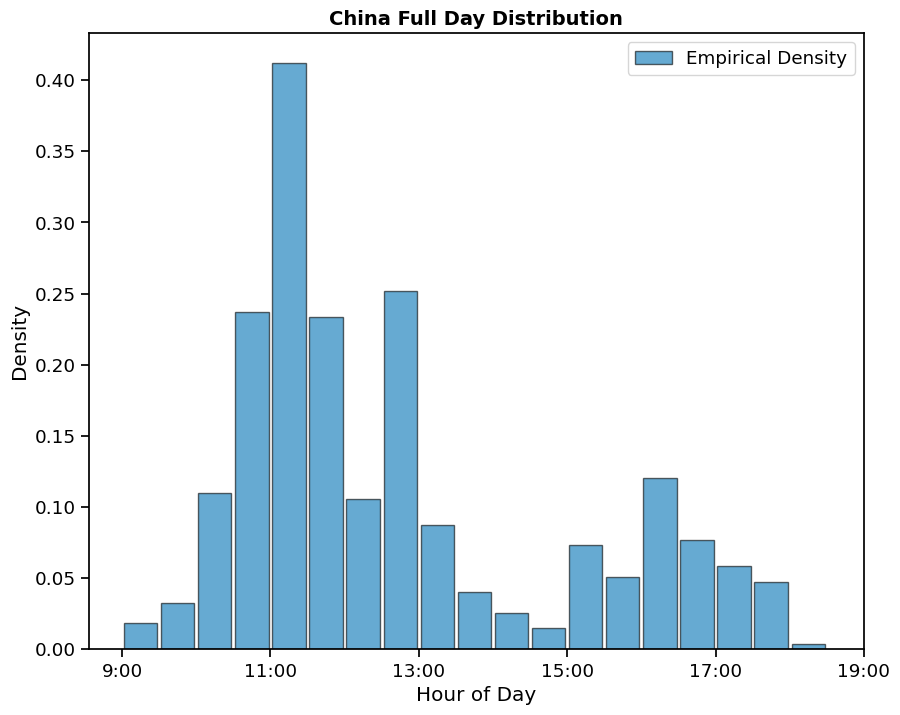

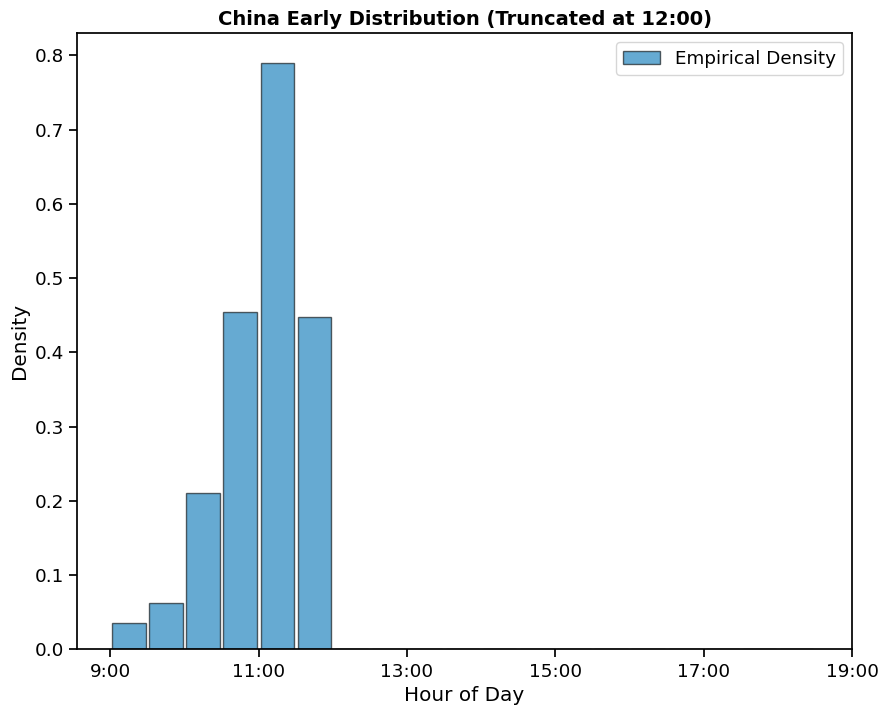

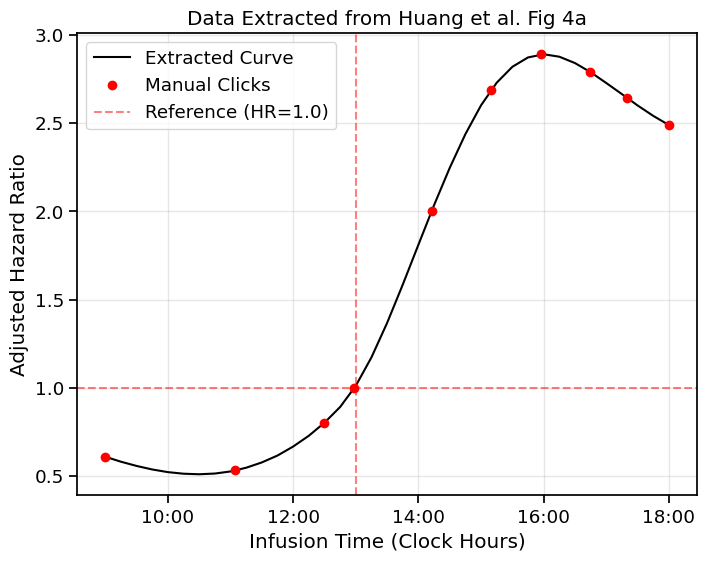


RUNNING CHINA COHORT | CUTOFF: 12:00 | ADHERENCE: 100.0%

--- Running Analysis (1000 repeats) ---

=== MONTE CARLO RESULTS (MEDIANS) ===
Median HR: 0.6036 | Median P: 1.4759e-05 | Power: 99.3%

FINAL AGGREGATED RESULTS (China | Cutoff: 12:00 | Adherence: 100.0%)
Hazard Ratio (HR):
  Mean         : 0.6069
  Median       : 0.6036
  95% CI       : [0.4713, 0.7475]
  % HR < 0.8   : 99.3%

Log-Rank P-Value:
  Power (p<.05): 99.3%



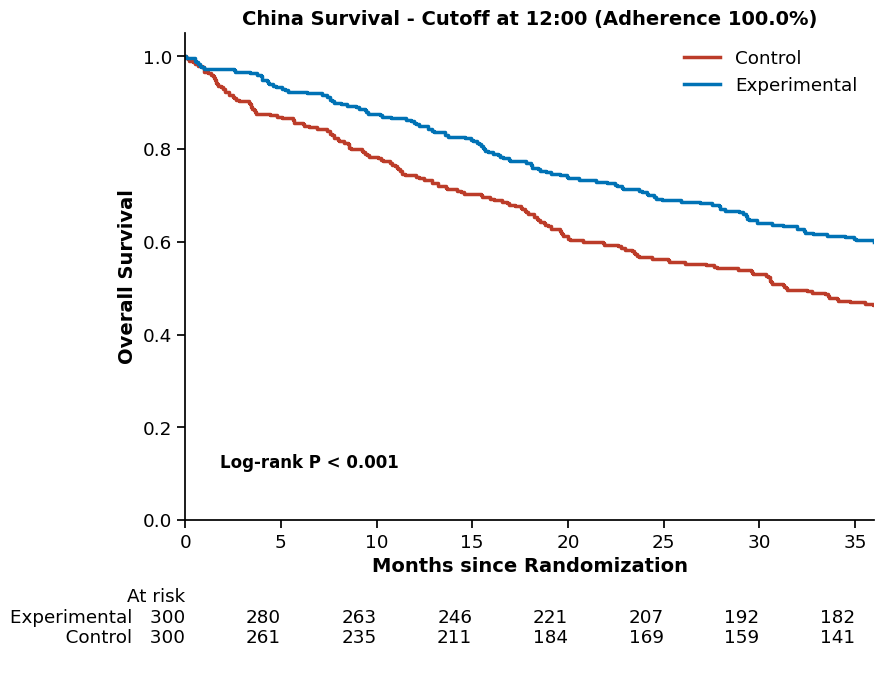

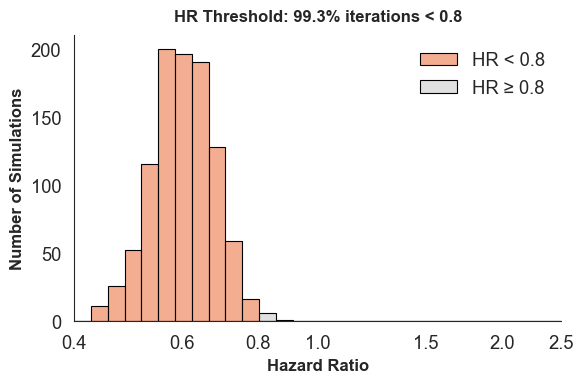

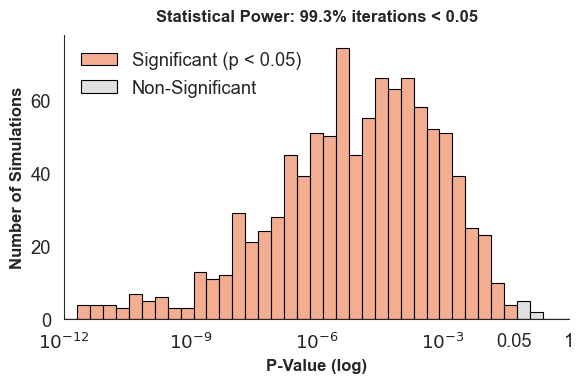


RUNNING CHINA COHORT | CUTOFF: 12:00 | ADHERENCE: 75.0%

--- Running Analysis (1000 repeats) ---

=== MONTE CARLO RESULTS (MEDIANS) ===
Median HR: 0.6924 | Median P: 1.1769e-03 | Power: 90.7%

FINAL AGGREGATED RESULTS (China | Cutoff: 12:00 | Adherence: 75.0%)
Hazard Ratio (HR):
  Mean         : 0.6944
  Median       : 0.6924
  95% CI       : [0.5544, 0.8552]
  % HR < 0.8   : 90.6%

Log-Rank P-Value:
  Power (p<.05): 90.7%



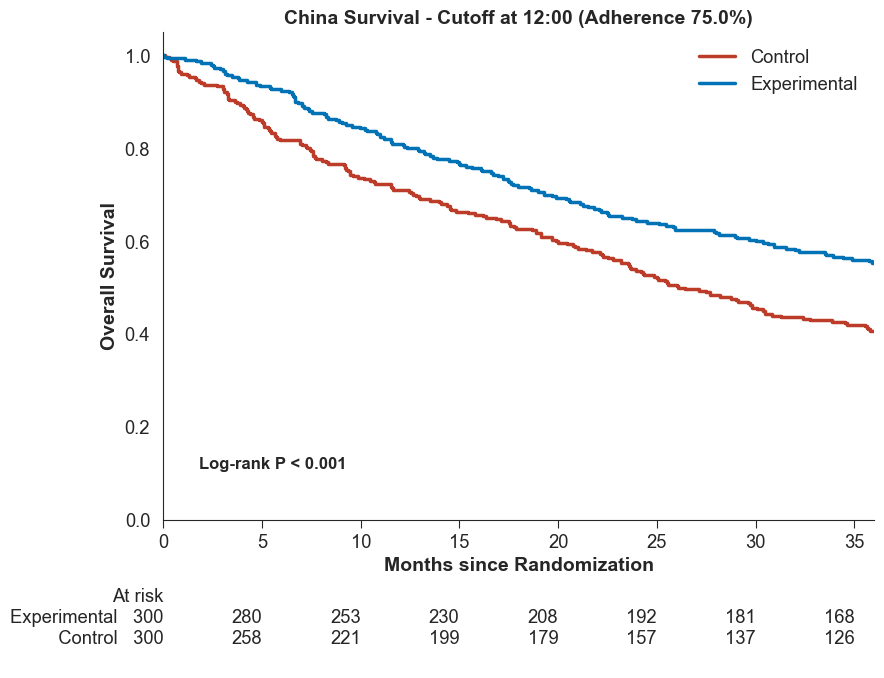

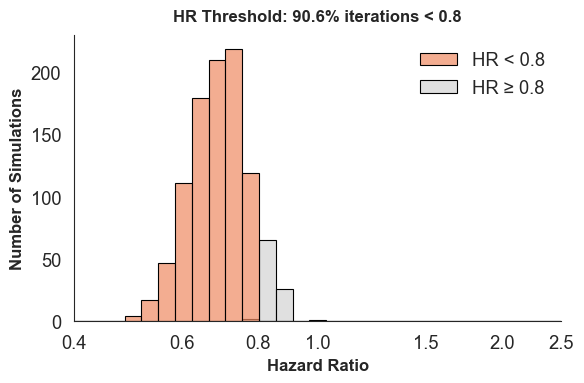

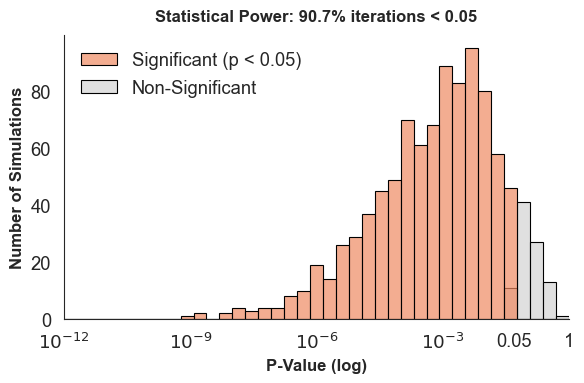


RUNNING CHINA COHORT | CUTOFF: 12:00 | ADHERENCE: 50.0%

--- Running Analysis (1000 repeats) ---

=== MONTE CARLO RESULTS (MEDIANS) ===
Median HR: 0.7818 | Median P: 2.8302e-02 | Power: 58.5%

FINAL AGGREGATED RESULTS (China | Cutoff: 12:00 | Adherence: 50.0%)
Hazard Ratio (HR):
  Mean         : 0.7873
  Median       : 0.7818
  95% CI       : [0.6286, 0.9691]
  % HR < 0.8   : 57.7%

Log-Rank P-Value:
  Power (p<.05): 58.9%



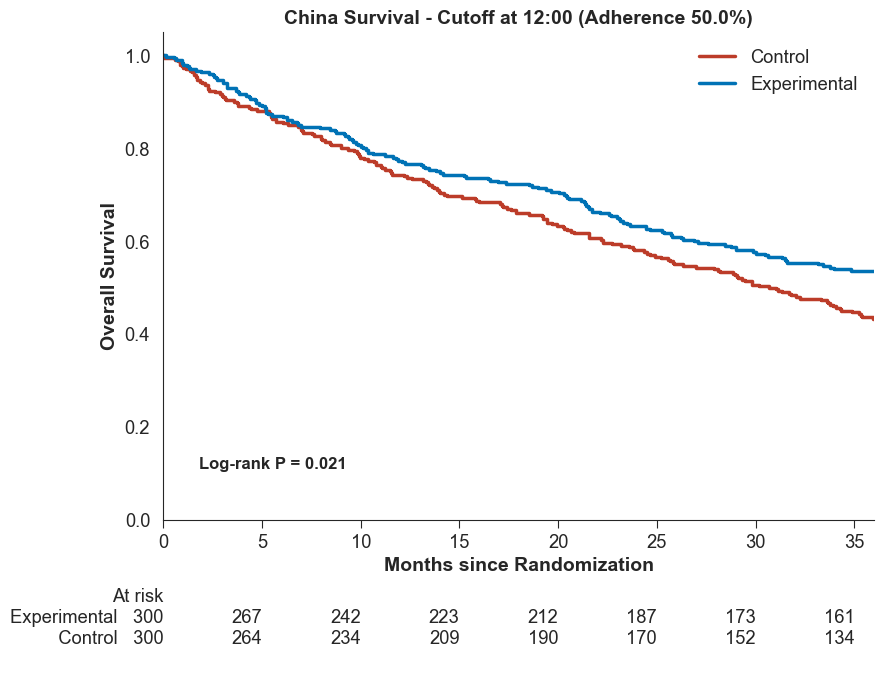

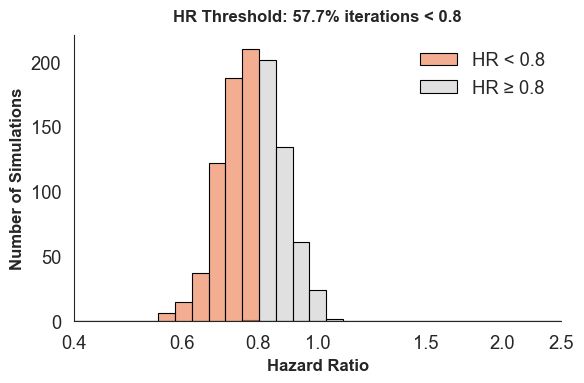

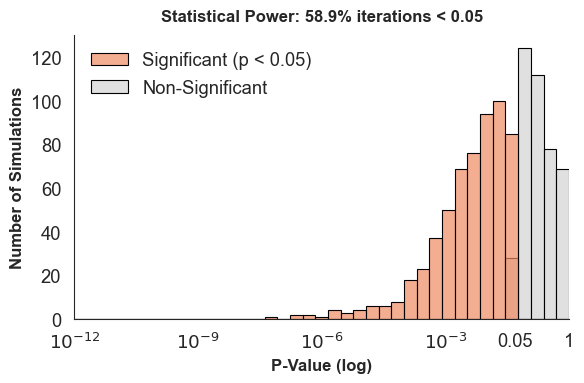


Success! All China results saved to: results/2026-02-26_09-24-43/China/


In [6]:
main_runner(ACTIVE_COHORT='China')

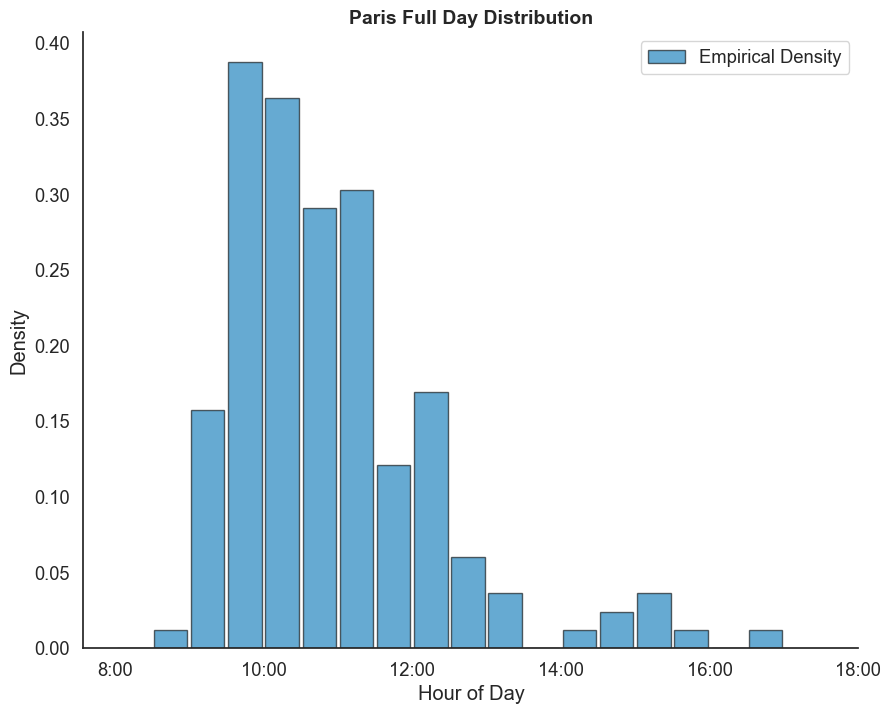

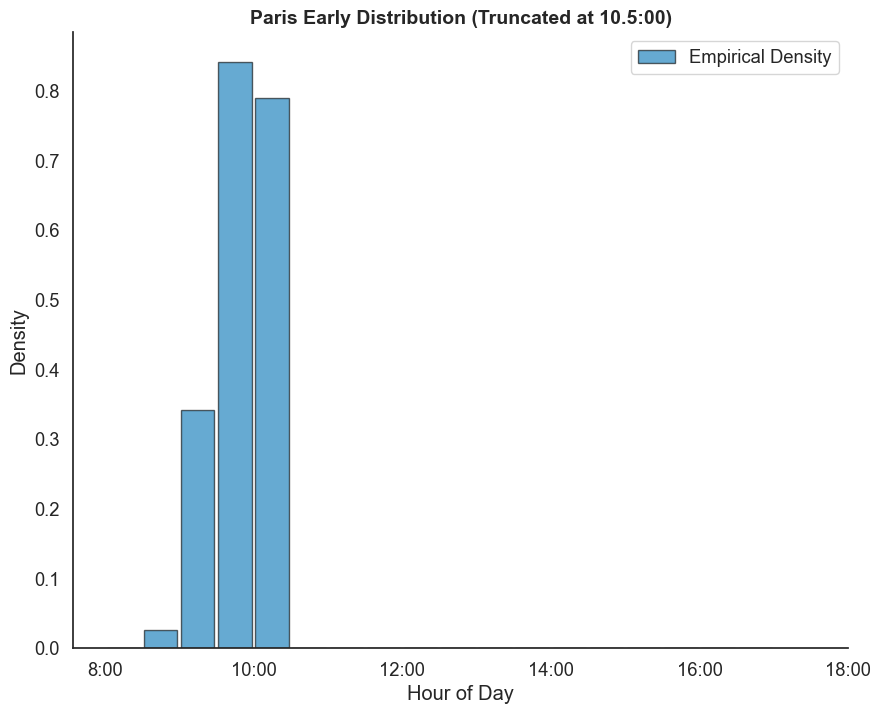

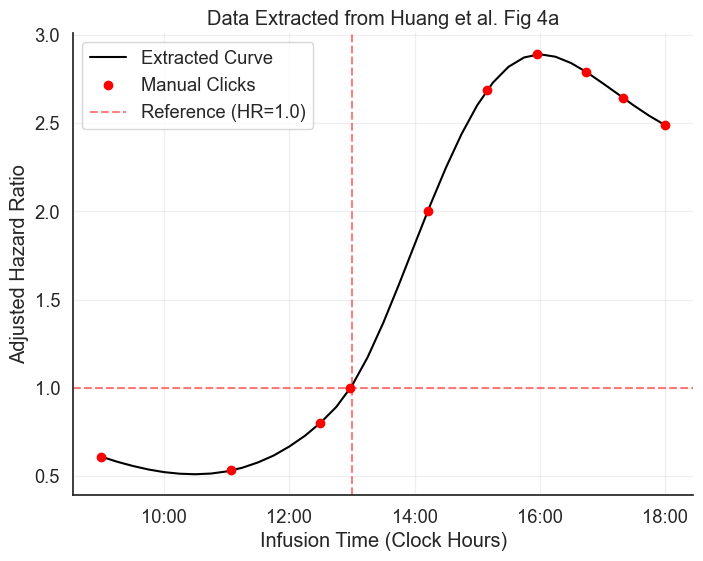


RUNNING PARIS COHORT | CUTOFF: 10.5:00 | ADHERENCE: 100.0%

--- Running Analysis (1000 repeats) ---

=== MONTE CARLO RESULTS (MEDIANS) ===
Median HR: 0.8582 | Median P: 2.1830e-01 | Power: 22.8%

FINAL AGGREGATED RESULTS (Paris | Cutoff: 10.5:00 | Adherence: 100.0%)
Hazard Ratio (HR):
  Mean         : 0.8638
  Median       : 0.8582
  95% CI       : [0.6797, 1.0759]
  % HR < 0.8   : 28.3%

Log-Rank P-Value:
  Power (p<.05): 23.0%



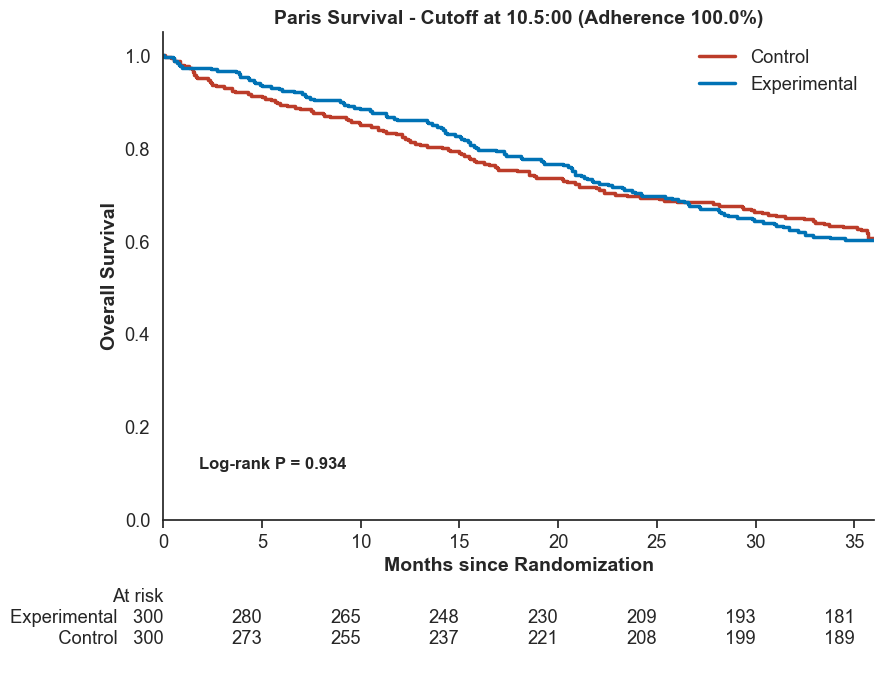

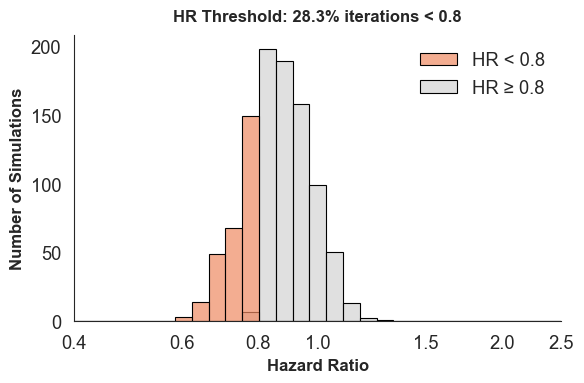

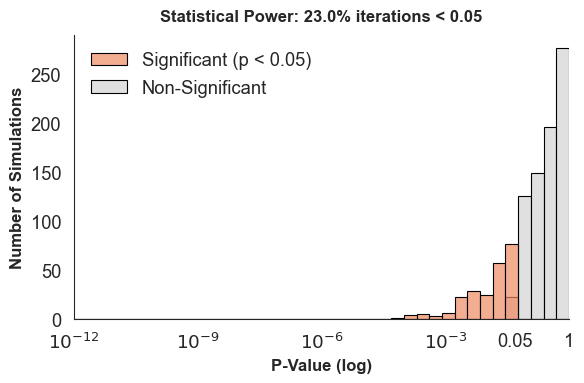


RUNNING PARIS COHORT | CUTOFF: 10.5:00 | ADHERENCE: 75.0%

--- Running Analysis (1000 repeats) ---

=== MONTE CARLO RESULTS (MEDIANS) ===
Median HR: 0.8989 | Median P: 3.4291e-01 | Power: 15.3%

FINAL AGGREGATED RESULTS (Paris | Cutoff: 10.5:00 | Adherence: 75.0%)
Hazard Ratio (HR):
  Mean         : 0.9028
  Median       : 0.8989
  95% CI       : [0.6972, 1.1361]
  % HR < 0.8   : 18.9%

Log-Rank P-Value:
  Power (p<.05): 15.4%



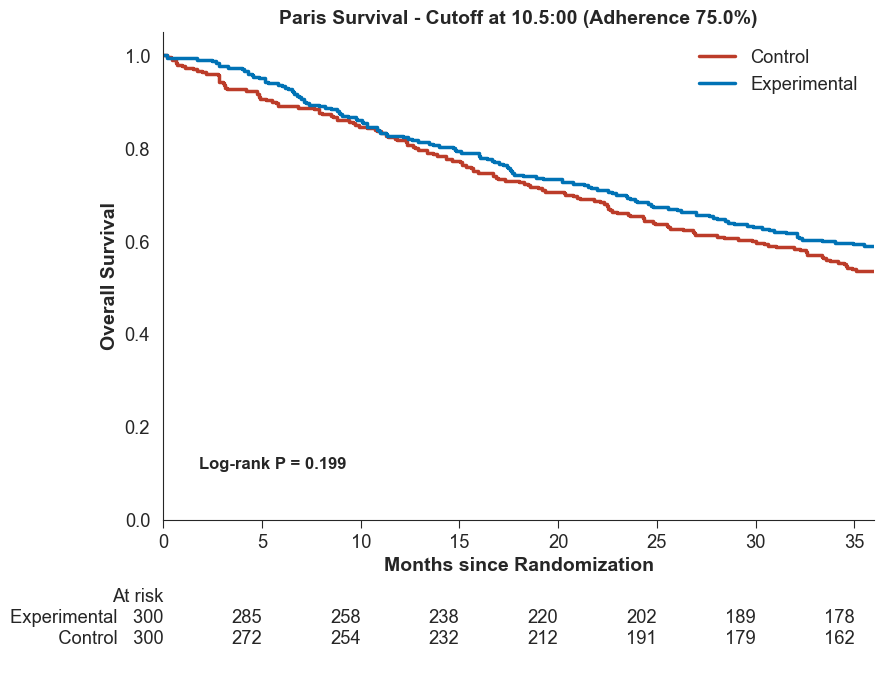

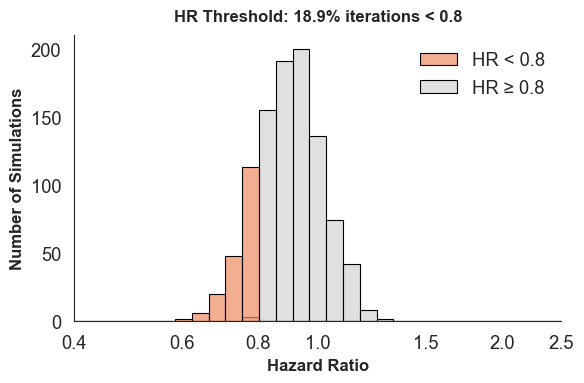

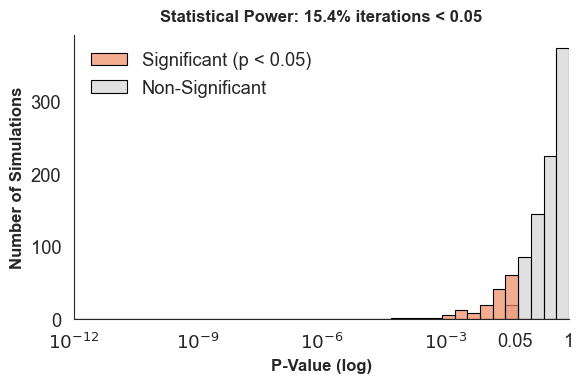


RUNNING PARIS COHORT | CUTOFF: 10.5:00 | ADHERENCE: 50.0%

--- Running Analysis (1000 repeats) ---

=== MONTE CARLO RESULTS (MEDIANS) ===
Median HR: 0.9240 | Median P: 3.9536e-01 | Power: 8.2%

FINAL AGGREGATED RESULTS (Paris | Cutoff: 10.5:00 | Adherence: 50.0%)
Hazard Ratio (HR):
  Mean         : 0.9331
  Median       : 0.9240
  95% CI       : [0.7423, 1.1699]
  % HR < 0.8   : 11.1%

Log-Rank P-Value:
  Power (p<.05): 8.4%



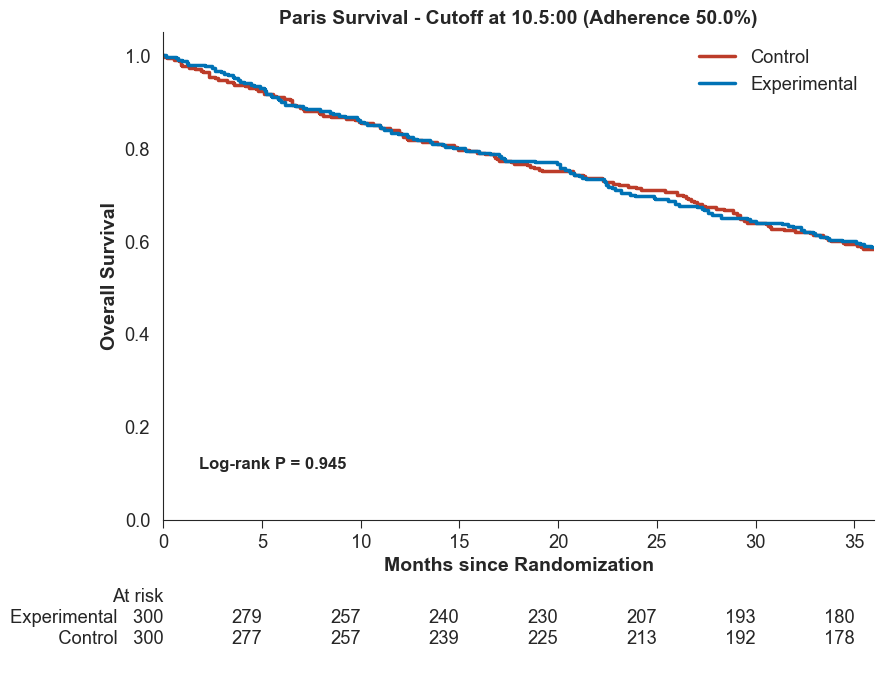

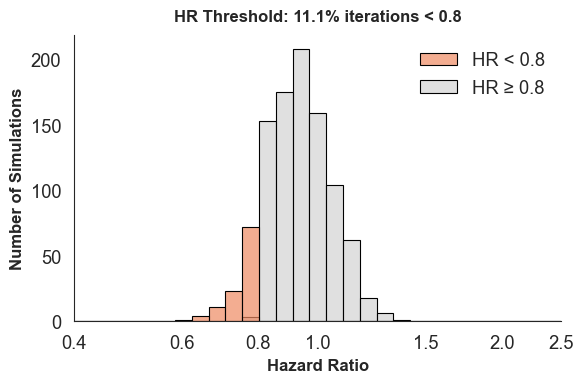

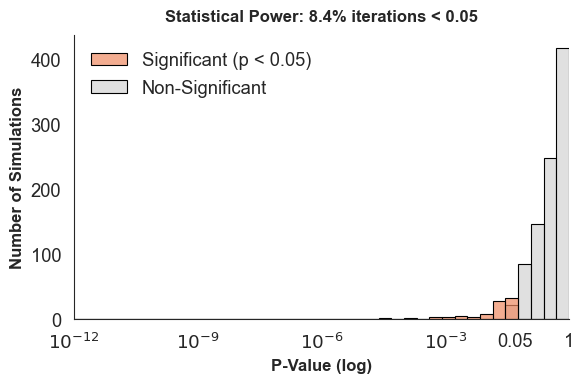


Success! All Paris results saved to: results/2026-02-26_09-25-57/Paris/


In [7]:
main_runner(ACTIVE_COHORT='Paris')

In [ ]:
# ==============================================================================
# MAIN FIGURE 2:
# ==============================================================================

LEFT: Log-rank P = 0.695
RIGHT: Multivariate P = 1.000726897122382e-07
Figure Saved to results/2026-02-26_09-40-30


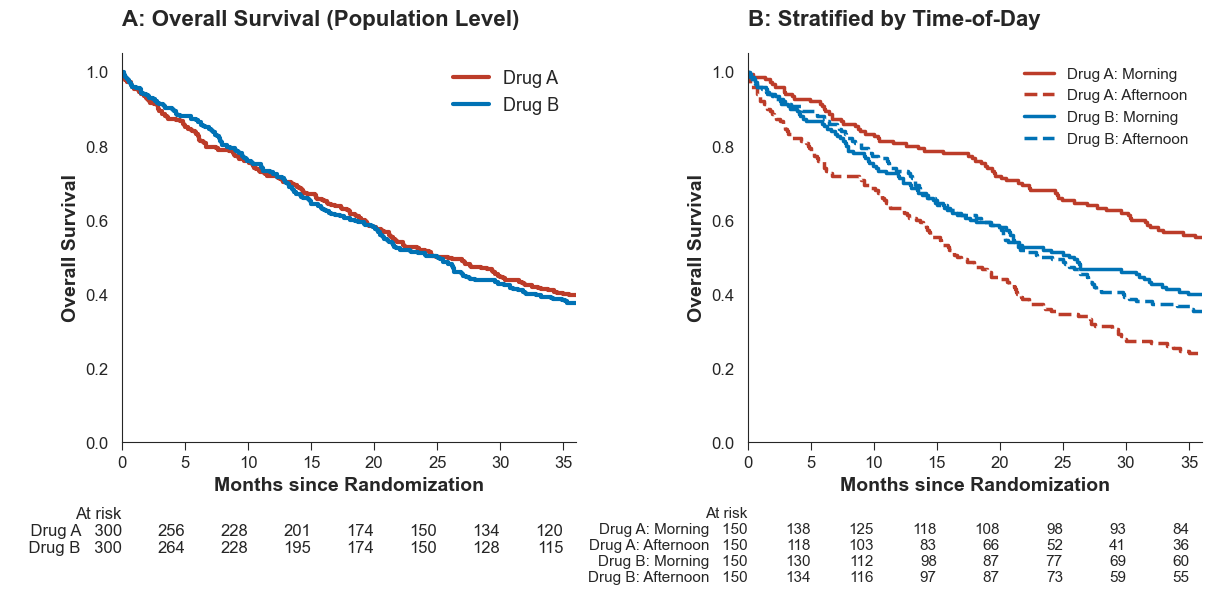


STATISTICAL SUMMARY

1. OVERALL MULTIVARIATE LOG-RANK TEST
------------------------------


<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 3
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
          35.40 <0.005     23.25


STATISTICAL SUMMARY: MULTIPLE TESTING CORRECTION

2. PAIRWISE LOG-RANK TEST (Subgroup Analysis)
Primary Reference: Drug A Morning
Correction Method: Bonferroni (Multiplicity adjustment for 6 tests)
-------------------------------------------------------------------------------------------------------------------
                          Comparison  test_statistic            p  p_corrected (Bonf)  Significant
  Drug A Morning vs Drug A Afternoon       35.479090 2.578033e-09        1.546820e-08         True
  Drug A Morning vs Drug B Afternoon       12.468102 4.139604e-04        2.483762e-03         True
    Drug A Morning vs Drug B Morning        8.062705 4.518568e-03        2.711141e-02         True
  Drug A Afternoon vs Drug B Morning        9.059252 2.613688e-03        1.568213e-02         True
Drug A Afternoon vs Drug B Afternoon        6.182559 1.290156e-02        7.740934e-02        False
  Drug B Afternoon vs Drug B Morning        0.348957 5.547041e-01        1.000000e+00      

In [15]:
# ==============================================================================
# 1. CONFIGURATION & DATA GENERATION
# ==============================================================================
# np.random.seed(7)
np.random.seed(43)
N_PATIENTS = 150 # per subgroup (Morning and Afternoon) for each drug, total 600 patients, 300 per drug
MEDIAN_OS_BASELINE = 25.5
FOLLOW_UP_TIME = 36.0

base_path =  f"results/{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}"
if not os.path.exists(base_path):
    os.makedirs(base_path)

# Values calculated from the system: 
# 1. HR_morning = HR_afternoon * 0.42 (according to results from Huang et al.)
# 2. (HR_morning + HR_afternoon) / 2 = 1 (mean HR)
HR_PARAMS = {
    'A_Morning': 0.6, # 0.59155,   # Calculated HR_morning
    'A_Afternoon': 1.4, # 1.40845, # Calculated HR_afternoon
    'B_Morning': 1.0,       # Reference: No effect
    'B_Afternoon': 1.0      # Reference: No effect
}

def generate_survival_times(n, hr, baseline_median, k=1):
    lambda_base = baseline_median / (np.log(2) ** (1/k))
    lambda_adj = lambda_base * (hr ** (-1/k))
    u = np.random.uniform(0, 1, n)
    return lambda_adj * ((-np.log(u)) ** (1/k))

def apply_censoring(df, limit):
    mask = df['Time'] > limit
    df.loc[mask, 'Event'] = 0      
    df.loc[mask, 'Time'] = limit   
    return df

def get_simulated_data(n_m=150, n_a=150):
    # Drug A
    t_m_a = generate_survival_times(n_m, HR_PARAMS['A_Morning'], MEDIAN_OS_BASELINE)
    t_a_a = generate_survival_times(n_a, HR_PARAMS['A_Afternoon'], MEDIAN_OS_BASELINE)
    df_A = pd.DataFrame({
        'Time': np.concatenate([t_m_a, t_a_a]), 'Event': 1, 
        'Timing': 'Morning', 'Drug': 'Drug A'
    })
    df_A.iloc[n_m:, df_A.columns.get_loc('Timing')] = 'Afternoon'
    
    # Drug B
    t_m_b = generate_survival_times(n_m, HR_PARAMS['B_Morning'], MEDIAN_OS_BASELINE)
    t_a_b = generate_survival_times(n_a, HR_PARAMS['B_Afternoon'], MEDIAN_OS_BASELINE)
    df_B = pd.DataFrame({
        'Time': np.concatenate([t_m_b, t_a_b]), 'Event': 1, 
        'Timing': 'Morning', 'Drug': 'Drug B'
    })
    df_B.iloc[n_m:, df_B.columns.get_loc('Timing')] = 'Afternoon'
    
    return apply_censoring(df_A, FOLLOW_UP_TIME), apply_censoring(df_B, FOLLOW_UP_TIME)

# ==============================================================================
# 2. PLOTTING HELPERS
# ==============================================================================
def apply_nejm_base_style(ax, title):
    ax.set_ylim(0, 1.05)
    ax.set_xlim(0, FOLLOW_UP_TIME)
    ax.set_title(title, loc='left', fontweight='bold', fontsize=16, pad=20)
    ax.set_ylabel("Overall Survival", fontweight='bold', fontsize=14)
    ax.set_xlabel("Months since Randomization", fontweight='bold', fontsize=14)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)
    ax.tick_params(axis='both', which='major', labelsize=12)

# ==============================================================================
# 3. STATISTICAL ANALYSIS & VISUALIZATION
# ==============================================================================
df_A, df_B = get_simulated_data(n_a=N_PATIENTS, n_m=N_PATIENTS)
C_RED, C_BLUE = '#BC3C29', '#0072B5'

# Combined dataframe for multivariate and pairwise tests
df_combined = pd.concat([df_A, df_B])
df_combined['Combined_Group'] = df_combined['Drug'] + " " + df_combined['Timing']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

# --- PANEL 1: POPULATION LEVEL ---
kmf_a_pop, kmf_b_pop = KaplanMeierFitter(), KaplanMeierFitter()
kmf_a_pop.fit(df_A['Time'], df_A['Event'], label="Drug A")
kmf_b_pop.fit(df_B['Time'], df_B['Event'], label="Drug B")

kmf_a_pop.plot_survival_function(ax=ax1, color=C_RED, linewidth=3, ci_show=False, show_censors=False)
kmf_b_pop.plot_survival_function(ax=ax1, color=C_BLUE, linewidth=3, ci_show=False, show_censors=False)

apply_nejm_base_style(ax1, "A: Overall Survival (Population Level)")
res_pop = logrank_test(df_A['Time'], df_B['Time'], df_A['Event'], df_B['Event'])
# ax1.text(0.05, 0.12, f"Log-rank P = {res_pop.p_value:.3f}", transform=ax1.transAxes, fontweight='bold', fontsize=14)
print(f"LEFT: Log-rank P = {res_pop.p_value:.3f}")
ax1.legend(frameon=False, loc='upper right', fontsize=13)

# --- PANEL 2: STRATIFIED SUBGROUPS ---
groups = [
    (df_A[df_A['Timing'] == 'Morning'],   C_RED,  '-',  "Drug A: Morning"),
    (df_A[df_A['Timing'] == 'Afternoon'], C_RED,  '--', "Drug A: Afternoon"),
    (df_B[df_B['Timing'] == 'Morning'],   C_BLUE, '-',  "Drug B: Morning"),
    (df_B[df_B['Timing'] == 'Afternoon'], C_BLUE, '--', "Drug B: Afternoon")
]

kmfs_strat = []
for df_sub, color, style, label in groups:
    kmf = KaplanMeierFitter()
    kmf.fit(df_sub['Time'], df_sub['Event'], label=label)
    kmf.plot_survival_function(ax=ax2, color=color, linestyle=style, linewidth=2.5, ci_show=False, show_censors=False)
    kmfs_strat.append(kmf)

apply_nejm_base_style(ax2, "B: Stratified by Time-of-Day")

# CALC MULTIVARIATE P-VALUE (Global Test)
res_multi = multivariate_logrank_test(df_combined['Time'], df_combined['Combined_Group'], df_combined['Event'])
# ax2.text(0.05, 0.12, f"Multivariate P {'< 0.001' if res_multi.p_value < 0.001 else f'= {res_multi.p_value:.3f}'}", 
        #  transform=ax2.transAxes, fontweight='bold', fontsize=14)
print(f"RIGHT: Multivariate P = {res_multi.p_value }")


ax2.legend(frameon=False, loc='upper right', fontsize=11)

# --- ADD AT-RISK TABLES ---
add_at_risk_counts(kmf_a_pop, kmf_b_pop, ax=ax1, rows_to_show=['At risk'], fontsize=12)
add_at_risk_counts(*kmfs_strat, ax=ax2, rows_to_show=['At risk'], fontsize=11)

save_name = f'Stratified_Trial_N.svg'
save_path = os.path.join(base_path, save_name)
plt.savefig(save_path, dpi=300, format='svg')
print(f"Figure Saved to {base_path}")

plt.show()

# ==============================================================================
# 4. CONSOLE LOGS: MULTIVARIATE & PAIRWISE RESULTS
# ==============================================================================
print("\n" + "="*50)
print("STATISTICAL SUMMARY")
print("="*50)

print("\n1. OVERALL MULTIVARIATE LOG-RANK TEST")
print("-" * 30)
res_multi.print_summary()

# print("\n2. PAIRWISE LOG-RANK TEST (Subgroup Analysis)")
# print("-" * 30)
# This evaluates all possible combinations
pairwise_results = pairwise_logrank_test(df_combined['Time'], df_combined['Combined_Group'], df_combined['Event'])
# print(pairwise_results.summary[['test_statistic', 'p', '-log2(p)']])


# ==============================================================================
# 4. CONSOLE LOGS: MULTIVARIATE & PAIRWISE RESULTS (WITH CORRECTION)
# ==============================================================================
print("\n" + "="*115)
print("STATISTICAL SUMMARY: MULTIPLE TESTING CORRECTION")
print("="*115)

# 1. Calculate Pairwise Log-Rank
pairwise_results = pairwise_logrank_test(df_combined['Time'], df_combined['Combined_Group'], df_combined['Event'])
summary_df = pairwise_results.summary[['test_statistic', 'p', '-log2(p)']].copy()

# 2. Apply Bonferroni Correction
reject, p_corrected, _, _ = multipletests(summary_df['p'], alpha=0.05, method='bonferroni')
summary_df['p_corrected (Bonf)'] = p_corrected
summary_df['Significant'] = reject

# 3. Custom Sorting & Labeling: Prioritize 'Drug A Morning'
primary_group = 'Drug A Morning'
comparison_labels = []
is_primary_flag = []

# Iterating through the index for custom labeling and flagging
for g1, g2 in summary_df.index:
    # If the primary group is present, ensure it is listed first in the string
    if g2 == primary_group:
        comparison_labels.append(f"{g2} vs {g1}")
        is_primary_flag.append(1)
    elif g1 == primary_group:
        comparison_labels.append(f"{g1} vs {g2}")
        is_primary_flag.append(1)
    else:
        comparison_labels.append(f"{g1} vs {g2}")
        is_primary_flag.append(0)

# Add our new columns to the dataframe
summary_df['Comparison'] = comparison_labels
summary_df['is_primary'] = is_primary_flag

# Sort: 'is_primary' first (descending), then by raw 'p' value (ascending)
summary_df = summary_df.sort_values(by=['is_primary', 'p'], ascending=[False, True])

# 4. Final Formatting and Printing
print("\n2. PAIRWISE LOG-RANK TEST (Subgroup Analysis)")
print(f"Primary Reference: {primary_group}")
print("Correction Method: Bonferroni (Multiplicity adjustment for 6 tests)")
print("-" * 115)

# Style for clinical output
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.precision', 6)

# Select and reorder columns for the final table
final_output = summary_df[['Comparison', 'test_statistic', 'p',  'p_corrected (Bonf)', 'Significant']]

print(final_output.to_string(index=False))
